![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Técnicas de agrupamiento

## Objetivos

- Entender los métodos de clustering K-means, jerárquico y DBSCAN.
- Generar agrupamientos con los métodos de clustering previamente indicados y realizar una comparativa.
- Investigar sobre una técnica de agrupamiento con un caso de uso concreto.


## Descripción de la actividad

El conjunto de datos con el cual vamos a trabajar se encuentra en el siguiente enlace: https://www.kaggle.com/datasets/umerrtx/machine-failure-prediction-using-sensor-data

Este conjunto de datos contiene datos de sensores recopilados de varias máquinas, con el objetivo de predecir fallos de las máquinas con antelación. Incluye una variedad de lecturas de sensores, así como las fallas de la máquina registradas.

### Tareas a realizar
- Clustering
  - Debes completar el código pedido en este notebook y contestar las preguntas finales.
  - Buscar dos artículos científicos (https://scholar.google.es/) con un caso de uso de técnicas de agrupamiento. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para cada artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la detección de anomalías.
    - Técnicas de detección de anomalías empleadas.
    - Principales resultados de la aplicación y de la investigación.


#### Nombre del estudiante

In [ ]:
# Luis Eduardo Tejada Vicente

### Clustering

Comenzamos importando las librerías necesarias y cargando el dataset.

Este archivo contiene 944 mediciones de sensores de diferentes máquinas, contiene una etiqueta de si tiene fallo o no.

Notas:
1. footfall: The number of people or objects passing by the machine.
2. tempMode: The temperature mode or setting of the machine.
3. AQ: Air quality index near the machine.
4. USS: Ultrasonic sensor data, indicating proximity measurements.
5. CS: Current sensor readings, indicating the electrical current usage of the machine.
6. VOC: Volatile organic compounds level detected near the machine.
7. RP: Rotational position or RPM (revolutions per minute) of the machine parts.
8. IP: Input pressure to the machine.
9. Temperature: The operating temperature of the machine.
10. fail: Binary indicator of machine failure (1 for failure, 0 for no failure).

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# se carga el dataset, con separados
df = pd.read_csv('data.csv', sep=',')

#### ¿Cuántas instancias tiene el dataset?

In [ ]:
n_instancias = df.shape[0]   # filas
n_columnas = df.shape[1]     # columnas

print(f"Instancias (filas): {n_instancias}")
print(f"Atributos/columnas: {n_columnas}")

df.head()

Instancias (filas): 944
Atributos/columnas: 10


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


#### ¿Cuál es el tipo de datos predominante en el dataset?

In [ ]:
# Tipos de datos por columna
print("Tipos por columna:")
print(df.dtypes)

# Conteo de tipos de datos y tipo predominante
tipo_counts = df.dtypes.value_counts()
print("\nConteo de tipos de datos:")
print(tipo_counts)

tipo_predominante = tipo_counts.idxmax()
porcentaje = (tipo_counts.max() / len(df.columns)) * 100
print(f"\nTipo predominante: {tipo_predominante} "
      f"({tipo_counts.max()} de {len(df.columns)} columnas, {porcentaje:.1f}%)")

# Resumen por familias de tipos
familias = {
    "numéricas": df.select_dtypes(include="number").columns.tolist(),
    "objetos/strings": df.select_dtypes(include="object").columns.tolist(),
    "booleanas": df.select_dtypes(include="bool").columns.tolist(),
    "fechas": df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist(),
}
print("\nResumen por familias:")
for fam, cols in familias.items():
    print(f"- {fam}: {len(cols)} columnas -> {cols}")

Tipos por columna:
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object

Conteo de tipos de datos:
int64    10
Name: count, dtype: int64

Tipo predominante: int64 (10 de 10 columnas, 100.0%)

Resumen por familias:
- numéricas: 10 columnas -> ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
- objetos/strings: 0 columnas -> []
- booleanas: 0 columnas -> []
- fechas: 0 columnas -> []


#### ¿Son variables continuas o categóricas?

La mayoría de las columnas son numéricas, la columna fail si bien solo responde a 2 números, 0 y 1 en la práctica se puede considerar categórica binaria y tempMode es categórica ordinal.

#### ¿cuáles son los valores mínimo y máximo de la variable 'RP'?

In [ ]:
rp_min = df['RP'].min()
rp_max = df['RP'].max()
print(f"RP - mínimo: {rp_min}, máximo: {rp_max}")

RP - mínimo: 19, máximo: 91


El valor mínimo para la variable RP es 19 y el máximo 91.

#### Para los algoritmos de clustering el dataset no puede tener instancias con datos faltantes. ¿Tiene este dataset datos faltantes?

In [ ]:
faltantes_por_col = df.isna().sum()
total_faltantes = faltantes_por_col.sum()

print("Faltantes por columna:")
print(faltantes_por_col)
print(f"\nTotal de faltantes en el dataset: {total_faltantes}")

Faltantes por columna:
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64

Total de faltantes en el dataset: 0


No existen datos faltantes.



#### Elimine la variable fail

In [ ]:
df.drop(columns=['fail'], inplace=True)
print("Columnas df:", list(df.columns))

Columnas df: ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature']


#### ¿Es necesario hacer algún tratamiendo adicional sobre los datos?

In [ ]:
X = df.copy()
ranges = (X.max() - X.min())
scale_spread = ranges.max() / ranges[ranges > 0].min()

print("Rangos por columna:")
print(ranges.sort_values(ascending=False))

Rangos por columna:
footfall       7300
RP               72
Temperature      23
tempMode          7
AQ                6
CS                6
USS               6
VOC               6
IP                6
dtype: int64


Los rangos muestran disparidad. Sin escalar, footfall dominaría las distancias y sesgaría K-Means/DBSCAN.

In [ ]:
from sklearn.preprocessing import StandardScaler
Xs = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)
print(Xs.shape)

(944, 9)


In [ ]:
chk = Xs.describe().T[['mean','std','min','max']].round(3)
print(chk)

             mean    std    min    max
footfall     -0.0  1.001 -0.283  6.463
tempMode      0.0  1.001 -1.393  1.223
AQ            0.0  1.001 -2.313  1.860
USS          -0.0  1.001 -1.402  2.936
CS           -0.0  1.001 -3.464  1.266
VOC          -0.0  1.001 -1.251  1.390
RP           -0.0  1.001 -1.708  2.678
IP            0.0  1.001 -2.231  1.523
Temperature   0.0  1.001 -2.567  1.284


## K-Means

Crea 10 modelos de KMeans y entrénalos. Haciendo uso del método indicado para saber el número ideal de clústeres.

Modelos entrenados: 10 (k=1..10)


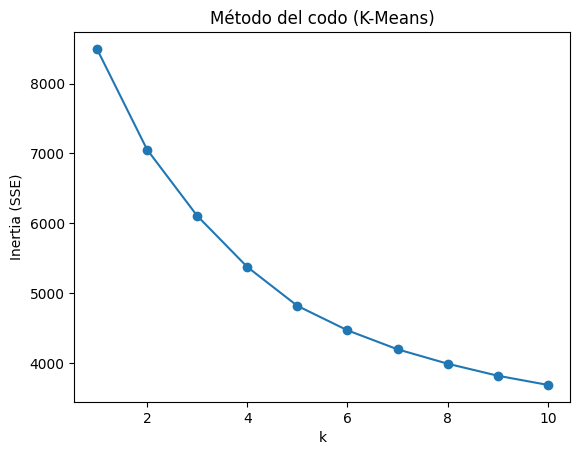

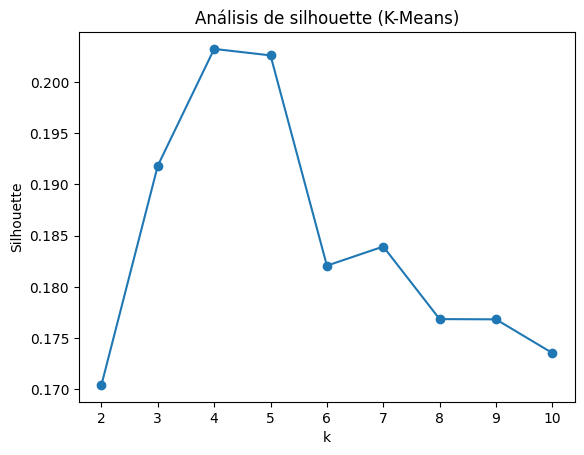

Mejor k por silhouette: k=4 (score=0.203)
Tamaños de clúster:
kmeans_k4
0    379
1    213
2    334
3     18
Name: count, dtype: int64


In [ ]:
# === K-Means: modelos (k=1..10) + elbow method e silhouette index ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

k_range = range(1, 11)  # 10 modelos
models = {}
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Xs)
    models[k] = km
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels) if k >= 2 else np.nan)

print(f"Modelos entrenados: {len(models)} (k=1..10)")

# --- Gráfico elbow method ---
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia (SSE)')
plt.title('Método del codo (K-Means)')
plt.show()

# --- Gráfico silhouette index ---
plt.figure()
plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Análisis de silhouette (K-Means)')
plt.show()

# --- k recomendado por silhouette ---
best_k = int(np.nanargmax(sil_scores) + 1)  # +1 porque sil_scores[0] es k=1 (NaN)
print(f"Mejor k por silhouette: k={best_k} (score={sil_scores[best_k-1]:.3f})")

# Etiquetas del mejor modelo (sin modificar Xs)
kmeans_best = models[best_k]
labels_best = pd.Series(kmeans_best.labels_, name=f'kmeans_k{best_k}')
print("Tamaños de clúster:")
print(labels_best.value_counts().sort_index())

Ahora toca interpretar lo que Kmeans ha realizado. Recordemos que el objetivo de KMeans es encontrar patrones en los datos.

Lo primero que vamos a realizar es un gráfico para visualizar los clústers que ha creado con base en las variables utilizadas para crearlos.

In [ ]:
import plotly.express as px

clusters = pd.DataFrame(Xs, columns=df.columns)
clusters['label'] = kmeans_best.labels_.astype(str)

polar = clusters.groupby("label").mean().reset_index()
polar = pd.melt(polar, id_vars=["label"], var_name="variable", value_name="value")

fig4 = px.line_polar(polar, r="value", theta="variable", color="label",
                     line_close=True, height=800, width=600)
fig4.show()

## DBSCAN

In [ ]:
#### Realiza una búsqueda de los mejores hiperparámetros para el algoritmo

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X = Xs.values
n_samples, n_features = X.shape

min_samples_grid = sorted(set([max(3, n_features//2), n_features, n_features+2, n_features+4, 15]))

def kdist_eps_candidates(X, k, q_list=(0.85, 0.90, 0.92, 0.94, 0.96, 0.98)):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nn.kneighbors(X)
    k_dists = np.sort(dists[:, -1])
    return [float(np.quantile(k_dists, q)) for q in q_list]

eps_candidates = set()
for m in min_samples_grid:
    eps_candidates.update(kdist_eps_candidates(X, k=m))
eps_grid = sorted(eps_candidates)

results = []
for m in min_samples_grid:
    for eps in eps_grid:
        db = DBSCAN(eps=eps, min_samples=m, metric='euclidean', n_jobs=-1)
        labels = db.fit_predict(X)

        noise_ratio = float(np.mean(labels == -1))
        unique_labels = set(labels) - {-1}
        n_clusters = len(unique_labels)

        # Silhouette sobre puntos no ruidosos y con >=2 clusters
        if n_clusters >= 2:
            mask = labels != -1
            try:
                sil = float(silhouette_score(X[mask], labels[mask]))
            except Exception:
                sil = np.nan
        else:
            sil = np.nan

        results.append({
            'eps': eps,
            'min_samples': m,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette': sil
        })

results_df = pd.DataFrame(results)

valid = results_df.dropna(subset=['silhouette'])
if not valid.empty and (valid['n_clusters'] >= 2).any():
    best_row = (valid[valid['n_clusters'] >= 2]
                .sort_values(by=['silhouette','noise_ratio','n_clusters'],
                             ascending=[False, True, False])
                .iloc[0])
else:
    # Si ninguna combinación produce >=2 clusters válidos, elegir la que más clusters tenga y menos ruido
    best_row = (results_df
                .sort_values(by=['n_clusters','noise_ratio'], ascending=[False, True])
                .iloc[0])

best_eps = float(best_row['eps'])
best_min_samples = int(best_row['min_samples'])

print("Top 10 combinaciones por silhouette (válidas):")
display(valid.sort_values(by=['silhouette','noise_ratio','n_clusters'],
                          ascending=[False, True, False]).head(10))

print("\nMejores hiperparámetros encontrados:")
print(f"- eps = {best_eps:.4f}")
print(f"- min_samples = {best_min_samples}")
print(f"- n_clusters = {int(best_row['n_clusters'])} | noise_ratio = {best_row['noise_ratio']:.2%} "
      f"| silhouette = {best_row['silhouette'] if not np.isnan(best_row['silhouette']) else 'NaN'}")

Top 10 combinaciones por silhouette (válidas):


,eps,min_samples,n_clusters,noise_ratio,silhouette
4,2.182343,4,2,0.038136,0.491223
8,2.323408,4,2,0.026483,0.490221
5,2.206985,4,2,0.034958,0.489737
6,2.254235,4,2,0.032839,0.489586
9,2.399812,4,2,0.020127,0.489169
10,2.413712,4,2,0.020127,0.489169
29,3.742571,4,2,0.000000,0.488939
59,3.742571,9,2,0.000000,0.488939
89,3.742571,11,2,0.000000,0.488939
15,2.565098,4,2,0.011653,0.488589



Mejores hiperparámetros encontrados:
- eps = 2.1823
- min_samples = 4
- n_clusters = 2 | noise_ratio = 3.81% | silhouette = 0.4912226968097434


In [ ]:
#### Entrenar el algoritmo DBSCAN con los hiperparámetros encontrados

In [ ]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='euclidean', n_jobs=-1)
db_labels = dbscan.fit_predict(Xs)

# Resumen de resultados
labels_series = pd.Series(db_labels, name='dbscan_label')
n_noise = int((db_labels == -1).sum())
noise_ratio = n_noise / len(db_labels)
clusters = sorted([c for c in set(db_labels) if c != -1])
n_clusters = len(clusters)

print(f"n_clusters (sin ruido): {n_clusters}")
print(f"ruido (-1): {n_noise} ({noise_ratio:.2%})")
print("tamaños por etiqueta (incluye -1 como ruido):")
print(labels_series.value_counts().sort_index())

# Silhouette sobre puntos no-ruido (solo si hay >=2 clústeres válidos)
if n_clusters >= 2:
    mask = db_labels != -1
    sil = silhouette_score(Xs[mask], db_labels[mask])
    print(f"silhouette (sin ruido): {sil:.3f}")
else:
    print("silhouette (sin ruido): NaN (requiere >=2 clústeres válidos)")

Xs_db = Xs.copy()
Xs_db['dbscan_label'] = labels_series

n_clusters (sin ruido): 2
ruido (-1): 36 (3.81%)
tamaños por etiqueta (incluye -1 como ruido):
dbscan_label
-1     36
 0    904
 1      4
Name: count, dtype: int64
silhouette (sin ruido): 0.491


In [ ]:
#### Elegir dos variables para visualizar los clústeres

In [ ]:
plot_df = Xs_db.copy()

var_x = 'footfall'
var_y = 'RP'

plot_df['label_str'] = plot_df['dbscan_label'].apply(lambda c: 'ruido (-1)' if c == -1 else f'cluster {c}')

fig = px.scatter(
    plot_df, x=var_x, y=var_y, color='label_str', symbol='label_str', opacity=0.75,
    title=f'DBSCAN — {var_x} vs {var_y}',
    labels={var_x: f'{var_x} (z-score)', var_y: f'{var_y} (z-score)'}
)

centroids = (plot_df[plot_df['dbscan_label'] != -1]
             .groupby('dbscan_label')[[var_x, var_y]]
             .median()
             .reset_index())
centroids['label_str'] = centroids['dbscan_label'].apply(lambda c: f'centro cluster {c}')
fig.add_scatter(
    x=centroids[var_x], y=centroids[var_y],
    mode='markers+text', name='centro (mediana)',
    marker=dict(size=14, symbol='x'),
    text=centroids['label_str'], textposition='top center'
)

fig.show()

## Dendrograma

In [ ]:
#### Aplica el algoritmo de AgglomerativeClustering a los datos

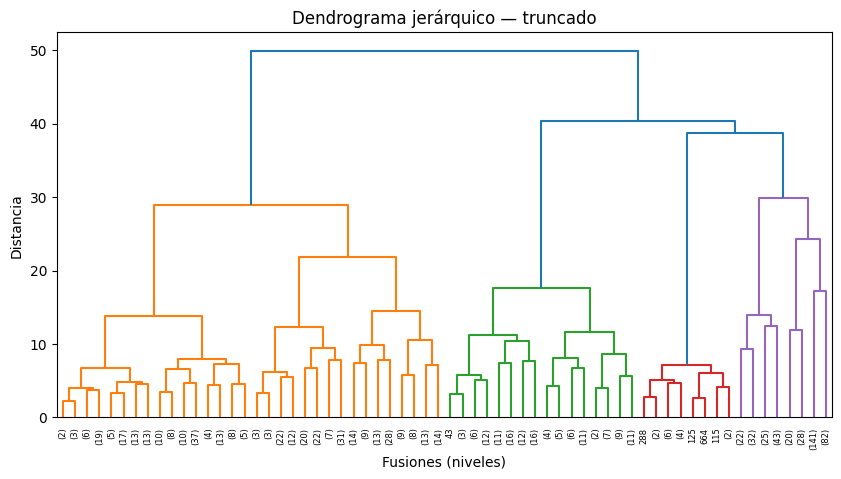

Primeras distancias de fusión: [0.    0.168 0.296 0.322 0.34  0.374 0.402 0.402 0.405 0.415]


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

hc = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.0,
    linkage='ward',
    compute_distances=True
).fit(Xs)


children = hc.children_
distances = hc.distances_
n_samples = hc.n_leaves_
counts = np.zeros(children.shape[0])

for i, (c1, c2) in enumerate(children):
    cnt = 0
    cnt += 1 if c1 < n_samples else counts[c1 - n_samples]
    cnt += 1 if c2 < n_samples else counts[c2 - n_samples]
    counts[i] = cnt

linkage_matrix = np.column_stack([children, distances, counts]).astype(float)


plt.figure(figsize=(10, 5))
sch.dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma jerárquico — truncado')
plt.xlabel('Fusiones (niveles)')
plt.ylabel('Distancia')
plt.show()


print("Primeras distancias de fusión:", np.round(distances[:10], 3))

In [ ]:
#### Realiza un análisis de cuál es el número ideal de clústeres y explique el porqué de su elección

Top por silhouette:
 k  silhouette  calinski_h  davies_b
 4    0.180284  154.743176  1.633255
 3    0.167338  150.527542  2.013435
 5    0.158556  145.820197  1.584398
 9    0.155560  123.463478  1.723971
 8    0.155442  131.287542  1.608223


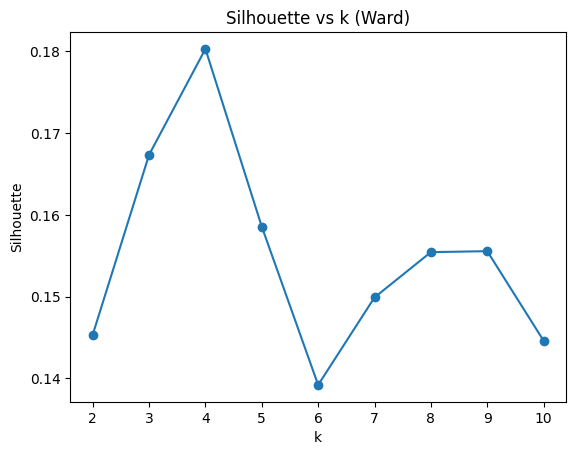

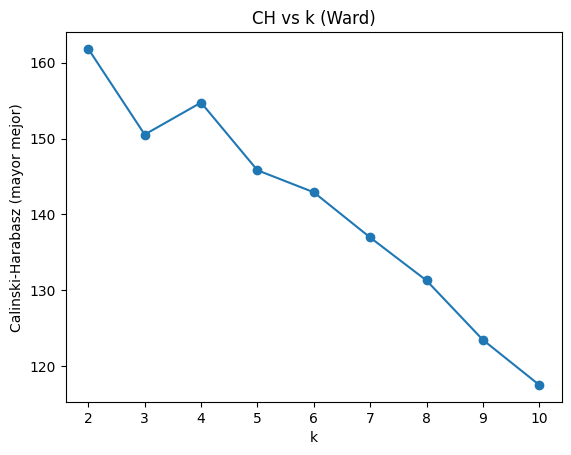

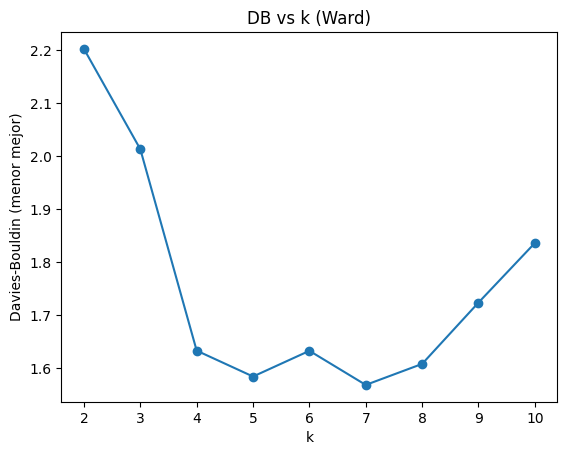


Recomendación por silhouette: k = 4 (sil=0.180)
Sugerencia por 'gran salto' en distancias (heurística): k ≈ 300

Elección final recomendada: k = 4 (criterio principal: silhouette)


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

Ks = range(2, 11)
rows = []
for k in Ks:
    ac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ac.fit_predict(Xs)
    sil = silhouette_score(Xs, labels)
    ch  = calinski_harabasz_score(Xs, labels)
    db  = davies_bouldin_score(Xs, labels)
    rows.append({"k": k, "silhouette": sil, "calinski_h": ch, "davies_b": db})

hc_grid = pd.DataFrame(rows)

print("Top por silhouette:")
print(hc_grid.sort_values("silhouette", ascending=False).head(5).to_string(index=False))

plt.figure(); plt.plot(hc_grid["k"], hc_grid["silhouette"], marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette vs k (Ward)"); plt.show()

plt.figure(); plt.plot(hc_grid["k"], hc_grid["calinski_h"], marker="o")
plt.xlabel("k"); plt.ylabel("Calinski-Harabasz (mayor mejor)"); plt.title("CH vs k (Ward)"); plt.show()

plt.figure(); plt.plot(hc_grid["k"], hc_grid["davies_b"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies-Bouldin (menor mejor)"); plt.title("DB vs k (Ward)"); plt.show()

k_sil = int(hc_grid.loc[hc_grid["silhouette"].idxmax(), "k"])
print(f"\nRecomendación por silhouette: k = {k_sil} "
      f"(sil={hc_grid['silhouette'].max():.3f})")

# Heurística de “big step” en el dendrograma
try:
    linkage_matrix
    distances = linkage_matrix[:, 2]
    n_samples = Xs.shape[0]
except NameError:
    hc_full = AgglomerativeClustering(
        n_clusters=None, distance_threshold=0.0, linkage='ward', compute_distances=True
    ).fit(Xs)
    children = hc_full.children_
    distances = hc_full.distances_
    n_samples = hc_full.n_leaves_
    counts = np.zeros(children.shape[0])
    for i, (c1, c2) in enumerate(children):
        cnt = (1 if c1 < n_samples else counts[c1 - n_samples]) + \
              (1 if c2 < n_samples else counts[c2 - n_samples])
        counts[i] = cnt
    linkage_matrix = np.column_stack([children, distances, counts]).astype(float)

tail = distances[-300:]
diffs = np.diff(tail)
jump_idx = np.argmax(diffs)
k_jump = jump_idx + 2
print(f"Sugerencia por 'gran salto' en distancias (heurística): k ≈ {k_jump}")

k_hc = k_sil
print(f"\nElección final recomendada: k = {k_hc} (criterio principal: silhouette)")

El máximo silhouette se obtuvo en k=4 (sil=0.180), por lo que es la elección más correcta. La heurística del “big step” en el dendrograma arrojó  aproximadamente 300, valor no interpretable/práctico en un árbol con 944 observaciones. Además, es coherente con K-Means, donde también emergió k=4 (sil=0.203). Por ello, fijamos k=4 como número de clústeres.

In [ ]:
#### Aplica de nuevo el clustering jerárquico con el número de clústeres elegido y crea un dataframe con los datos y las etiquetas otorgadas por el algoritmo.

In [ ]:

k_hc = 4
hc_final = AgglomerativeClustering(n_clusters=k_hc, linkage='ward')
hc_labels = hc_final.fit_predict(Xs)

df_hc = df.copy()
df_hc['hc_k4'] = hc_labels

print("Tamaños por clúster:")
print(df_hc['hc_k4'].value_counts().sort_index())


Tamaños por clúster:
hc_k4
0    393
1    401
2    132
3     18
Name: count, dtype: int64


## Análisis

#### Realiza un análisis detallado de cada uno de los grupos generados por los algoritmos aplicados anteriormente y decide cuál es el mejor método para el conjunto de datos.
Utiliza gráficos o tablas para apoyar tus conclusiones

=== Métricas comparativas ===
                 n_clusters  silhouette  calinski_h  davies_b  noise_ratio
method                                                                    
kmeans_k4                 4       0.203     181.829     1.515          NaN
hierarchical_k4           4       0.180     154.743     1.633          NaN
dbscan_best               2       0.491      23.361     0.627        0.038

Adjusted Rand Index (K-Means vs Jerárquico): 0.590

== K-Means k=4: perfiles en escala ORIGINAL ==
         footfall  tempMode    AQ   USS    CS   VOC     RP    IP  Temperature
cluster                                                                      
0          129.72      3.67  5.44  2.06  5.60  5.12  48.87  4.85        18.29
1          183.32      4.23  4.38  4.50  4.02  1.70  52.60  3.22        11.88
2          208.43      3.45  3.05  2.94  6.03  1.03  41.62  5.08        16.93
3         7300.00      4.17  3.94  3.00  5.50  2.00  43.61  4.78        16.72

== K-Means k=4: perfiles e

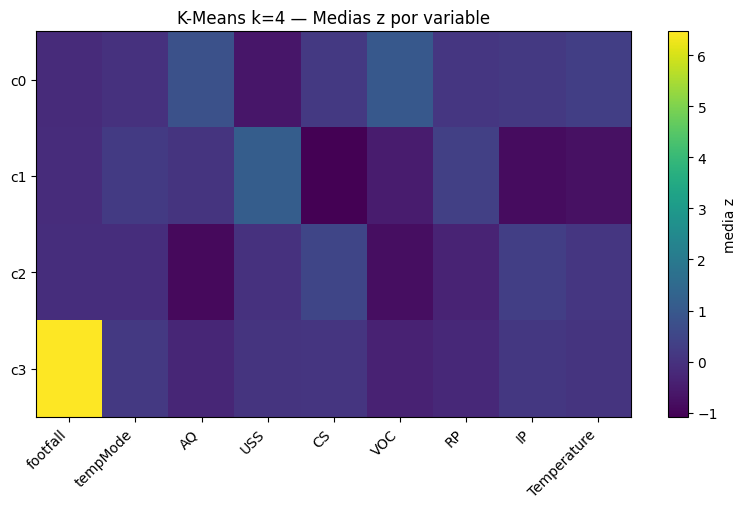

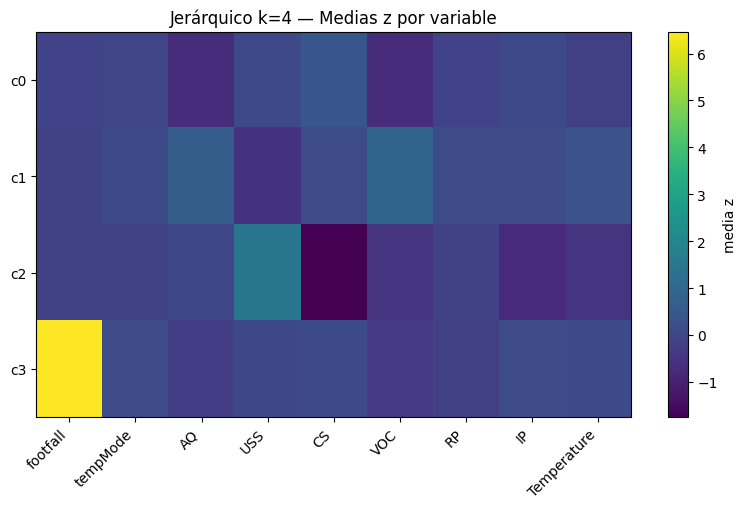

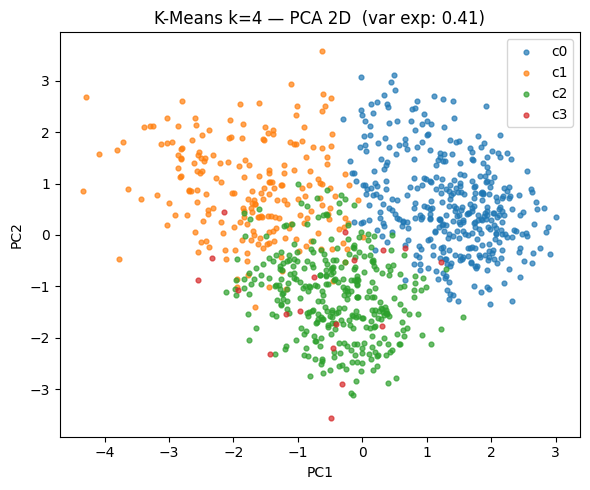

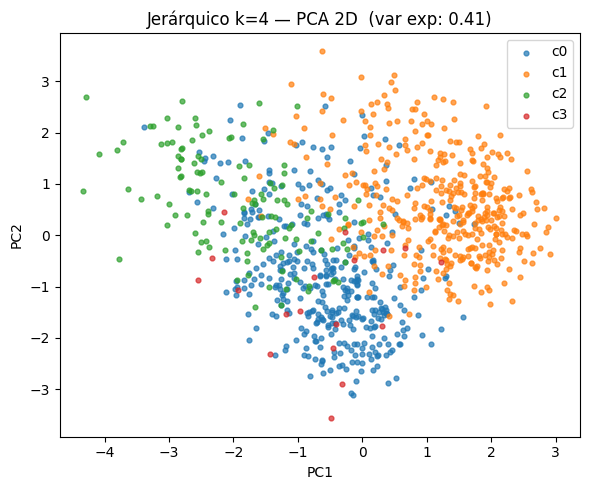

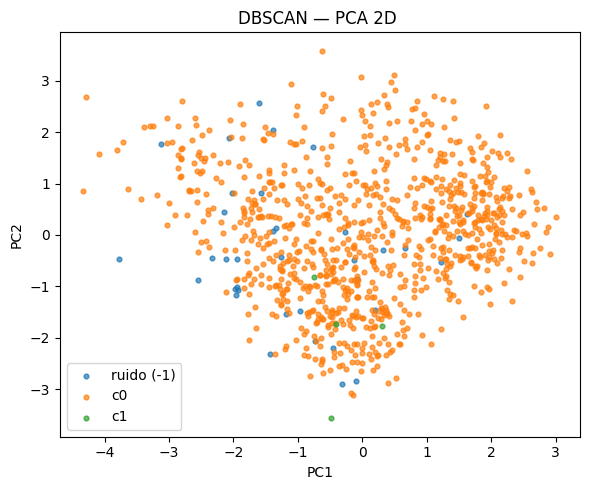

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Etiquetas disponibles de cada método:
# K-Means
km_labels = labels_best.values
# Jerárquico
hc_labels = df_hc['hc_k4'].values
# DBSCAN
db_labels = Xs_db['dbscan_label'].values

def metrics_all(X_scaled, labels, mask=None):
    """Devuelve métricas """
    if mask is None:
        mask = np.ones(len(labels), dtype=bool)
    L = labels[mask]
    X = X_scaled[mask]
    uniq = np.unique(L)
    out = {"n_clusters": len(uniq)}
    if len(uniq) >= 2:
        out["silhouette"] = float(silhouette_score(X, L))
        out["calinski_h"] = float(calinski_harabasz_score(X, L))
        out["davies_b"]  = float(davies_bouldin_score(X, L))
    else:
        out["silhouette"] = np.nan
        out["calinski_h"] = np.nan
        out["davies_b"]  = np.nan
    return out

# K-Means y Jerárquico
m_km = metrics_all(Xs.values, km_labels)
m_hc = metrics_all(Xs.values, hc_labels)

# DBSCAN: métricas
mask_nn = db_labels != -1
m_db = metrics_all(Xs.values, db_labels, mask=mask_nn)
m_db["noise_ratio"] = float((db_labels == -1).mean())

summary = pd.DataFrame([
    {"method":"kmeans_k4", **m_km},
    {"method":"hierarchical_k4", **m_hc},
    {"method":"dbscan_best", **m_db},
]).set_index("method").round(3)

print("=== Métricas comparativas ===")
print(summary)

# Acuerdo entre K-Means y Jerárquico
ari_km_hc = adjusted_rand_score(km_labels, hc_labels)
print(f"\nAdjusted Rand Index (K-Means vs Jerárquico): {ari_km_hc:.3f}")

# PERFILES DE CLÚSTER
def cluster_profiles(df_original, X_scaled, labels, name):
    df_tmp = df_original.copy()
    df_tmp["cluster"] = labels
    prof_orig = df_tmp.groupby("cluster").mean().round(2)
    Xz = pd.DataFrame(X_scaled, columns=df_original.columns)
    Xz["cluster"] = labels
    prof_z = Xz.groupby("cluster").mean().round(2)
    print(f"\n== {name}: perfiles en escala ORIGINAL ==")
    print(prof_orig)
    print(f"\n== {name}: perfiles en Z-score (↑positivo = por encima de la media) ==")
    print(prof_z)
    # Top variables por clúster
    print(f"\n{ name }: variables más distintivas por clúster")
    for c in prof_z.index:
        row = prof_z.loc[c]
        top_pos = row.sort_values(ascending=False).head(3).index.tolist()
        top_neg = row.sort_values().head(3).index.tolist()
        print(f" - cluster {c}: +{top_pos}  |  -{top_neg}")

cluster_profiles(df, Xs.values, km_labels, "K-Means k=4")
cluster_profiles(df, Xs.values, hc_labels, "Jerárquico k=4")

# HEATMAP de medias Z por clúster
def heatmap_cluster_means(X_scaled, labels, title):
    Z = pd.DataFrame(X_scaled, columns=df.columns)
    Z["cluster"] = labels
    M = Z.groupby("cluster").mean().reindex(sorted(np.unique(labels)))
    plt.figure(figsize=(8, 4 + 0.3*len(M)))
    plt.imshow(M.values, aspect="auto")
    plt.colorbar(label="media z")
    plt.yticks(range(len(M.index)), [f"c{c}" for c in M.index])
    plt.xticks(range(len(M.columns)), M.columns, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

heatmap_cluster_means(Xs.values, km_labels, "K-Means k=4 — Medias z por variable")
heatmap_cluster_means(Xs.values, hc_labels, "Jerárquico k=4 — Medias z por variable")

# PCA 2D para visualización
def pca_scatter(X_scaled, labels, title):
    pca = PCA(n_components=2, random_state=42)
    XY = pca.fit_transform(X_scaled)
    plt.figure(figsize=(6,5))
    for c in np.unique(labels):
        pts = XY[labels==c]
        plt.scatter(pts[:,0], pts[:,1], s=12, label=f"c{c}", alpha=0.7)
    plt.title(title + f"  (var exp: {pca.explained_variance_ratio_.sum():.2f})")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
    plt.tight_layout(); plt.show()

pca_scatter(Xs.values, km_labels, "K-Means k=4 — PCA 2D")
pca_scatter(Xs.values, hc_labels, "Jerárquico k=4 — PCA 2D")

# DBSCAN en PCA, incluyendo ruido:
def pca_scatter_dbscan(X_scaled, labels, title):
    pca = PCA(n_components=2, random_state=42)
    XY = pca.fit_transform(X_scaled)
    labs = np.array(labels)
    uniq = sorted(set(labs))
    plt.figure(figsize=(6,5))
    for c in uniq:
        pts = XY[labs==c]
        lbl = "ruido (-1)" if c == -1 else f"c{c}"
        plt.scatter(pts[:,0], pts[:,1], s=12, label=lbl, alpha=0.7)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
    plt.tight_layout(); plt.show()

pca_scatter_dbscan(Xs.values, db_labels, "DBSCAN — PCA 2D ")

El mejor método para este dataset es K-Means con k=4. En la comparación, K-Means supera al Jerárquico en métricas (silhouette 0.203 vs 0.180; CH 181.8 vs 154.7; DB 1.515 vs 1.633) y produce tres clústeres grandes + 1 micro-grupo muy claro (el de footfall=7300, detectado por ambos métodos). DBSCAN logra un silhouette alto solo en no-ruido (0.491), pero su partición es poco útil para segmentación (904/4 y 3.8% de ruido). La concordancia entre K-Means y Jerárquico (ARI=0.59) refuerza la estructura de 4 grupos, por lo que selecciono K-Means (k=4) como método final y se usaría DBSCAN solo como apoyo para detección de anomalías.

## Artículos de investigación

#### Artículo 1

Este artículo aplica clustering por densidad (DBSCAN) a datos de monitorización de condición de transformadores (gases disueltos en aceite) para detectar anomalías sin etiquetas, proponiendo vectores de características auxiliares por variable y una heurística para seleccionar parámetros mediante la curva “número de clústeres–Eps”; con ello distingue patrones normales, anomalías válidas e inválidas y, en comparación con métodos de referencia (kNN, LOF, RDOS, reglas estadísticas, EKPCA, iForest), obtiene mejores resultados en las métricas, de aproximadamente F = 0.96, y mayor estabilidad, sin recurrir a Deep Learning.

Liu, H., Wang, Y., & Chen, W. (2020). Anomaly detection for condition monitoring data using auxiliary feature vector and density-based clustering. IET Generation, Transmission & Distribution, 14(1), 108–118. https://doi.org/10.1049/iet-gtd.2019.0682

#### Artículo 2

El artículo propone un método de trabajo en dos fases para detectar anomalías de trayectorias humanas en interiores usando clustering DBSCAN. Primero agrupa trayectorias históricas y después verifica si una nueva trayectoria pertenece a algún clúster; se introduce una medida de similitud LCSS_IS (combina distancia de caminata indoor y etiquetas semánticas de lugares) y un índice de validez DCVI para seleccionar ε en DBSCAN; en los conjuntos MIT Badge y sCREEN detecta visitas a ubicaciones raras y anomalías en la ruta con un F1 de aproximaamente 89–94% (según tipo de anomalía).

Lan, D. T., & Yoon, S. (2023). Trajectory clustering-based anomaly detection in indoor human movement. Sensors, 23(6), 3318. https://doi.org/10.3390/s23063318